In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import relevant libraries for the classification task. 
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.neural_network import MLPClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm


from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedShuffleSplit, RepeatedStratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, QuantileTransformer, RobustScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, classification_report, make_scorer, confusion_matrix
from sklearn.feature_selection import  SelectKBest, f_classif, SelectPercentile

from collections import Counter

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier




In [ ]:
# Read csv data 
path = "/Users/bimphomthong/Library/Mobile Documents/com~apple~CloudDocs/Learning-icloud/data-science-ml/ml_ai_learning_by_doing/PIRvision_FoG_presence_detection/pirvision_fog_presence_detection/"
train_data1 = pd.read_csv(path + 'pirvision_office_dataset1.csv')
train_data2 = pd.read_csv(path + 'pirvision_office_dataset2.csv')

# concatenate the two dataframes row-wise
train_data = pd.concat([train_data1, train_data2], ignore_index=True)

# Check the data
display(train_data)

# Move the label column to the last column
label_col = train_data['Label'].copy()
train_data = train_data.drop(columns=['Label'])
train_data['target'] = label_col

# Check the data
display(train_data)

# summary of the data
display(train_data.describe())


In [20]:
# Read csv data 
path = "/Users/bimphomthong/Library/Mobile Documents/com~apple~CloudDocs/Learning-icloud/data-science-ml/ml_ai_learning_by_doing/PIRvision_FoG_presence_detection/pirvision_fog_presence_detection/"
train_data1 = pd.read_csv(path + 'pirvision_office_dataset1.csv')
train_data2 = pd.read_csv(path + 'pirvision_office_dataset2.csv')

# concatenate the two dataframes row-wise
train_data = pd.concat([train_data1, train_data2], ignore_index=True)

# Check the data
display(train_data)

# Move the label column to the last column
label_col = train_data['Label'].copy()
train_data = train_data.drop(columns=['Label'])
train_data['target'] = label_col

# summary of the data
train_data['target'] = train_data['target'].replace(3, 2)

# drop Date and Time columns
train_data = train_data.drop(columns=['Date', 'Time'])

# Check the data
display(train_data)
display(train_data.describe())





,Date,Time,Label,Temperature_F,PIR_1,PIR_2,PIR_3,PIR_4,PIR_5,PIR_6,...,PIR_46,PIR_47,PIR_48,PIR_49,PIR_50,PIR_51,PIR_52,PIR_53,PIR_54,PIR_55
0,2024-08-08,19:19:56,0,86,10269,10721,11156,11170,10931,10671,...,11178,11197,11161,11096,10957,10839,10735,10590,10411,10329
1,2024-08-08,19:20:12,1,86,10364,10907,11299,11238,10867,10535,...,11122,11145,11136,11108,11041,10824,10645,10493,10398,10357
2,2024-08-08,19:20:28,0,86,10329,10793,11197,11242,11052,10658,...,11168,11204,11162,11109,11007,10867,10700,10533,10427,10265
3,2024-08-08,19:20:44,0,86,10169,10425,10822,11133,11136,10834,...,11116,11273,11186,10984,10910,10807,10714,10651,10562,10463
4,2024-08-08,19:21:00,0,86,10320,10667,11104,11234,11129,10814,...,11006,11257,11370,11173,10924,10816,10754,10588,10428,10407
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15297,2024-10-08,04:34:17,0,88,10648,11474,11989,11891,11424,10861,...,11873,11947,11856,11725,11562,11335,11129,10820,10599,10438
15298,2024-10-08,04:34:33,0,88,10412,11083,11796,12000,11612,10999,...,11785,11948,11912,11811,11652,11430,11103,10829,10614,10465
15299,2024-10-08,04:34:49,0,88,10412,10780,11555,11860,11541,11101,...,11690,11815,11813,11746,11573,11395,11222,11070,10909,10696
15300,2024-10-08,04:35:05,0,88,10697,11502,12022,11957,11436,10794,...,11895,11989,11898,11672,11506,11189,10866,10700,10509,10426


,Temperature_F,PIR_1,PIR_2,PIR_3,PIR_4,PIR_5,PIR_6,PIR_7,PIR_8,PIR_9,...,PIR_47,PIR_48,PIR_49,PIR_50,PIR_51,PIR_52,PIR_53,PIR_54,PIR_55,target
0,86,10269,10721,11156,11170,10931,10671,10395,10133,9885,...,11197,11161,11096,10957,10839,10735,10590,10411,10329,0
1,86,10364,10907,11299,11238,10867,10535,10173,9950,9856,...,11145,11136,11108,11041,10824,10645,10493,10398,10357,1
2,86,10329,10793,11197,11242,11052,10658,10288,9988,9819,...,11204,11162,11109,11007,10867,10700,10533,10427,10265,0
3,86,10169,10425,10822,11133,11136,10834,10520,10228,9986,...,11273,11186,10984,10910,10807,10714,10651,10562,10463,0
4,86,10320,10667,11104,11234,11129,10814,10453,10040,9733,...,11257,11370,11173,10924,10816,10754,10588,10428,10407,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15297,88,10648,11474,11989,11891,11424,10861,10133,9633,9264,...,11947,11856,11725,11562,11335,11129,10820,10599,10438,0
15298,88,10412,11083,11796,12000,11612,10999,10339,9809,9467,...,11948,11912,11811,11652,11430,11103,10829,10614,10465,0
15299,88,10412,10780,11555,11860,11541,11101,10621,10005,9550,...,11815,11813,11746,11573,11395,11222,11070,10909,10696,0
15300,88,10697,11502,12022,11957,11436,10794,10228,9783,9373,...,11989,11898,11672,11506,11189,10866,10700,10509,10426,0


,Temperature_F,PIR_1,PIR_2,PIR_3,PIR_4,PIR_5,PIR_6,PIR_7,PIR_8,PIR_9,...,PIR_47,PIR_48,PIR_49,PIR_50,PIR_51,PIR_52,PIR_53,PIR_54,PIR_55,target
count,15302.000000,1.530200e+04,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,...,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000,15302.000000
mean,80.383871,2.501256e+05,11013.891648,11517.838452,11578.490786,11269.104169,10795.036989,10312.208600,9907.840413,9610.574958,...,11559.512874,11541.448438,11439.599529,11283.987061,11103.084564,10919.279441,10743.028624,10585.803294,10449.395373,0.258136
std,22.860670,4.292858e+06,591.779937,656.662381,663.090247,605.916326,537.230304,501.390737,499.616070,522.012929,...,627.975644,619.176515,598.543624,571.501348,546.292700,518.324545,487.192649,464.733099,450.216603,0.583769
min,0.000000,2.613000e+03,2615.000000,2614.000000,2611.000000,2612.000000,2613.000000,2616.000000,2614.000000,2615.000000,...,2606.000000,2606.000000,2605.000000,2605.000000,2609.000000,2605.000000,2604.000000,2603.000000,2602.000000,0.000000
25%,86.000000,1.033300e+04,10787.250000,11272.250000,11338.000000,11051.000000,10629.000000,10182.000000,9764.000000,9410.000000,...,11313.000000,11301.000000,11211.000000,11083.000000,10935.250000,10794.000000,10650.000000,10513.000000,10388.000000,0.000000
50%,86.000000,1.043100e+04,11002.000000,11557.000000,11629.000000,11301.000000,10790.000000,10311.000000,9910.000000,9597.000000,...,11583.000000,11566.000000,11471.000000,11319.000000,11137.000000,10948.000000,10760.000000,10597.000000,10454.000000,0.000000
75%,88.000000,1.056075e+04,11267.000000,11885.000000,11957.000000,11550.000000,10982.000000,10443.000000,10035.000000,9762.000000,...,11961.000000,11928.000000,11781.000000,11571.000000,11334.000000,11097.000000,10876.000000,10683.000000,10524.000000,0.000000
max,89.000000,1.116026e+08,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,...,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,16383.000000,2.000000


In [34]:
train_data

,Temperature_F,PIR_1,PIR_2,PIR_3,PIR_4,PIR_5,PIR_6,PIR_7,PIR_8,PIR_9,...,PIR_47,PIR_48,PIR_49,PIR_50,PIR_51,PIR_52,PIR_53,PIR_54,PIR_55,target
0,86,10269,10721,11156,11170,10931,10671,10395,10133,9885,...,11197,11161,11096,10957,10839,10735,10590,10411,10329,0
1,86,10364,10907,11299,11238,10867,10535,10173,9950,9856,...,11145,11136,11108,11041,10824,10645,10493,10398,10357,1
2,86,10329,10793,11197,11242,11052,10658,10288,9988,9819,...,11204,11162,11109,11007,10867,10700,10533,10427,10265,0
3,86,10169,10425,10822,11133,11136,10834,10520,10228,9986,...,11273,11186,10984,10910,10807,10714,10651,10562,10463,0
4,86,10320,10667,11104,11234,11129,10814,10453,10040,9733,...,11257,11370,11173,10924,10816,10754,10588,10428,10407,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15297,88,10648,11474,11989,11891,11424,10861,10133,9633,9264,...,11947,11856,11725,11562,11335,11129,10820,10599,10438,0
15298,88,10412,11083,11796,12000,11612,10999,10339,9809,9467,...,11948,11912,11811,11652,11430,11103,10829,10614,10465,0
15299,88,10412,10780,11555,11860,11541,11101,10621,10005,9550,...,11815,11813,11746,11573,11395,11222,11070,10909,10696,0
15300,88,10697,11502,12022,11957,11436,10794,10228,9783,9373,...,11989,11898,11672,11506,11189,10866,10700,10509,10426,0


----------------------------------------------------------------------------------------------------
Trained on 1530 samples and tested on 13772 samples
Number of features: 56
Class distribution in y_train: [1249  167  114]


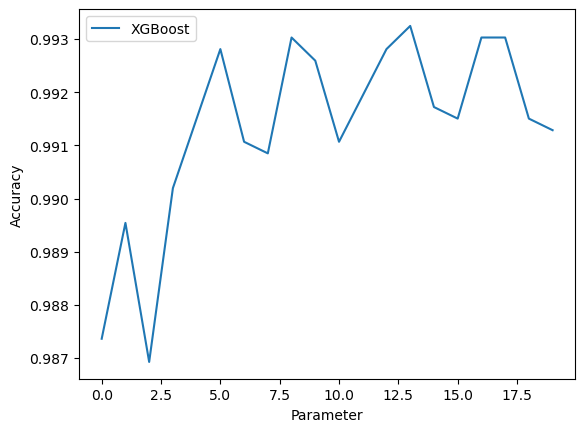

XGBoost best parameters: {'classifier__learning_rate': 0.0325, 'classifier__max_depth': 5, 'classifier__n_estimators': 200}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11245
           1       0.97      0.96      0.97      1499
           2       1.00      1.00      1.00      1028

    accuracy                           0.99     13772
   macro avg       0.99      0.99      0.99     13772
weighted avg       0.99      0.99      0.99     13772

XGBoost ROC AUC score (OVR, macro): 0.9992838246087841
----------------------------------------------------------------------------------------------------
Trained on 1530 samples and tested on 13772 samples
Number of features: 56
Class distribution in y_train: [1249  167  114]


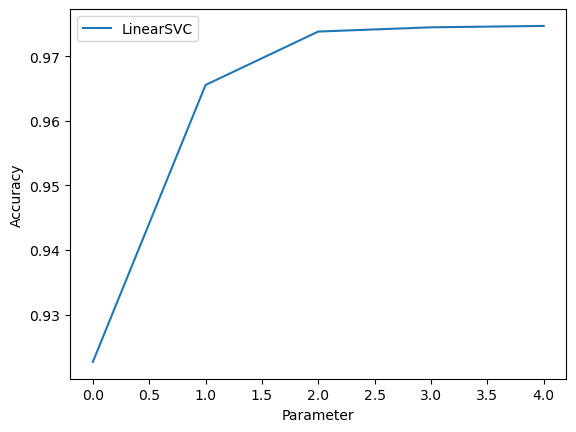

LinearSVC best parameters: {'classifier__estimator__C': 0.01}
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     11245
           1       0.96      0.81      0.88      1499
           2       1.00      0.95      0.97      1028

    accuracy                           0.97     13772
   macro avg       0.98      0.92      0.95     13772
weighted avg       0.97      0.97      0.97     13772

LinearSVC ROC AUC score (OVR, macro): 0.9985737216664017


In [33]:
classifiers = {'XGBoost': XGBClassifier(objective='multi:softmax', eval_metric='mlogloss'),
               #'Logistic Regression': LogisticRegression(class_weight='balanced', solver='liblinear'),
               #'Ridge Classifier': RidgeClassifier(class_weight='balanced'),
               'LinearSVC': CalibratedClassifierCV(LinearSVC(class_weight='balanced', max_iter=5000, dual = 'auto')),
               #'MLP': MLPClassifier(learning_rate='adaptive', max_iter=7000, solver='adam', activation='relu')
               }

accuracy_scores = []

# Load the data for each subjectLRL
 
X = train_data.drop(columns=['target']).copy()
#X = X[col]
y = train_data['target'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.9, random_state=42, shuffle=True, stratify=y)

# -- Train and test the classifiers --
grid_classifier = [] # Store the grid classifier for each subject

for classifier_idx, (name, classifier) in enumerate(classifiers.items()):
    print(f'-' * 100)
    print(f'Trained on {len(y_train)} samples and tested on {len(y_test)} samples')
    print(f'Number of features: {len(X_train.columns)}')
    print(f'Class distribution in y_train: {np.bincount(y_train)}')

    # define the scoring functions
    accuracy_scorer = make_scorer(accuracy_score)
    precision_scorer = make_scorer(precision_score, average='macro', zero_division=0)
    recall_scorer = make_scorer(recall_score, average='macro', zero_division=0)
    f1_scorer = make_scorer(f1_score, average='macro', zero_division=0)
    roc_auc_scorer = make_scorer(roc_auc_score, multi_class='ovr', average='macro', response_method='predict_proba')

    scoring = {
        'accuracy': accuracy_scorer,
        'roc_auc': roc_auc_scorer,
        'f1': f1_scorer
    }

    pipeline = Pipeline([
        ('feature_selection', SelectPercentile(f_classif, percentile=20)),
        ('scaler', StandardScaler()),
        #('robustscaler', RobustScaler()),
        #('pca', PCA(n_components=5)),
        ('classifier', classifier)
    ])

    # Define the parameter grid for the classifiers
    if name == 'Logistic Regression':
        param_grid = {
            #'pca__n_components': [i for i in range(2, int(max_features/2))],
            #'pca__n_components': [i for i in range(2, 10)],
            #'classifier__C': np.linspace(1.0, 2.0, 10)#,
            'classifier__C': np.logspace(-10, 2, 30)
        }
    
    elif name == 'Ridge Classifier':
        param_grid = {
            #'pca__n_components': [i for i in range(2, int(max_features/2))],
            #'pca__n_components': [i for i in range(2, 10)],
            'classifier__alpha': np.logspace(-5, 10, 30)
        }

    elif name == 'LinearSVC':
        param_grid = {
        #'pca__n_components': [i for i in range(2, 10)],
        'classifier__estimator__C': np.logspace(-4, 4, 5)
    }
    elif name == 'MLP':
        param_grid = {
            #'pca__n_components': [i for i in range(2, int(max_features/2))],
            #'pca__n_components': [i for i in range(2, 10)],
            'classifier__hidden_layer_sizes': [(12,8), (20,14), (28, 20)],
            'classifier__alpha': np.logspace(-3, 1, 10),
            'classifier__learning_rate': ['adaptive']
        }
    elif name == 'XGBoost':
        param_grid = {
            'classifier__n_estimators': [100, 200], # Number of trees
            'classifier__learning_rate': np.linspace(0.01, 0.1, 5), # Step size shrinkage
            'classifier__max_depth': [3, 5]        # Max depth of a tree
            #'classifier__scale_pos_weight': np.linspace(0.6, 4.0, 10)
        }

    
    # define the grid search
    cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)
    #grid = GridSearchCV(SVC(), param_grid=param_grid, cv=cv)
    grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring=scoring, refit='roc_auc', n_jobs=-1)

    # fit the grid search
    grid.fit(X_train, y_train)

    grid_classifier.append(grid)

    # -- Plotting mean accuracy of the current classifier parameter iteration i.e. rows of cv_results_ ---
    plt.plot(np.arange(len(grid.cv_results_['mean_test_accuracy'])), grid.cv_results_['mean_test_accuracy'], label=name)
    plt.xlabel('Parameter')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # --- Make classification report ---
    y_pred = grid.best_estimator_.predict(X_test)
    print(f'{name} best parameters: {grid.best_params_}')
    print(classification_report(y_test, y_pred, zero_division=0))
    
     # print ROC AUC score 
    # For multi-class ROC AUC, use predict_proba and specify multi_class strategy
    if hasattr(grid.best_estimator_, "predict_proba"):
        y_score = grid.best_estimator_.predict_proba(X_test)
        print(f'{name} ROC AUC score (OVR, macro): {roc_auc_score(y_test, y_score, multi_class="ovr", average="macro")}')
    else:
        # This case should be less likely now for LinearSVC due to CalibratedClassifierCV
        print(f'{name} does not support predict_proba. ROC AUC score (OVR, macro) cannot be calculated using probabilities.')


    